In [1]:
import os
import torch
import torch.nn.functional as F
from torch import Tensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
 
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_PATH  = r"C:\Users\lenovo LOQ\PFA2\Sorted"
MODEL_PATH = "malware_classifier.pth"
BATCH_SIZE = 32
 
# PGD parameters
EPSILON = 0.005   # max perturbation (pixel space)
ALPHA   = 0.001   # step size per iteration (pixel space)
STEPS   = 10      # number of iterations
 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
 

Using device: cuda


In [3]:
# ─────────────────────────────────────────────
# LOAD MODEL
# ─────────────────────────────────────────────
model = torch.jit.load(MODEL_PATH, map_location=device)
model.eval()
print(f"Model loaded from {MODEL_PATH}")
 

Model loaded from malware_classifier.pth


In [4]:
# ─────────────────────────────────────────────
# DATA
# ─────────────────────────────────────────────
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]
 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])
test_dataset = datasets.ImageFolder(os.path.join(DATA_PATH, "test"), transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Classes: {test_dataset.classes}")
 

Classes: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']


In [5]:
# ─────────────────────────────────────────────
# PGD ATTACK
# ─────────────────────────────────────────────
def pgd_attack(images: Tensor, labels: Tensor,
               epsilon: float = EPSILON,
               alpha: float   = ALPHA,
               steps: int     = STEPS,
               random_start: bool = True) -> Tensor:
    """
    PGD Attack (Madry et al.)
 
    Args:
        images:       clean normalised input batch  (B, C, H, W)
        labels:       true labels                   (B,)
        epsilon:      max perturbation budget in pixel space
        alpha:        step size per iteration in pixel space
        steps:        number of PGD iterations
        random_start: start from random point within epsilon ball
    """
    std     = torch.tensor(NORM_STD,  device=images.device).view(1, 3, 1, 1)
    mean    = torch.tensor(NORM_MEAN, device=images.device).view(1, 3, 1, 1)
    norm_min = (0.0 - mean) / std
    norm_max = (1.0 - mean) / std
 
    eps_n   = epsilon / std
    alpha_n = alpha   / std
 
    x_adv = images.clone().detach()
 
    # random start — helps escape local optima
    if random_start:
        noise = torch.empty_like(x_adv).uniform_(-1, 1) * eps_n
        x_adv = torch.clamp(x_adv + noise, norm_min, norm_max).detach()
 
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), labels)
        model.zero_grad()
        loss.backward()
 
        with torch.no_grad():
            # one FGSM step
            x_adv = x_adv + alpha_n * x_adv.grad.sign()
 
            # project back into epsilon ball around original image
            delta = torch.clamp(x_adv - images, -eps_n, eps_n)
 
            # keep within valid normalised range
            x_adv = torch.clamp(images + delta, norm_min, norm_max)
 
    return x_adv.detach()
 

In [6]:

# ─────────────────────────────────────────────
# VISUALIZE
# ─────────────────────────────────────────────
def show_pgd_examples(images: Tensor, labels: Tensor, n: int = 8):
    import matplotlib.pyplot as plt
 
    mean = torch.tensor(NORM_MEAN, device=images.device).view(3, 1, 1)
    std  = torch.tensor(NORM_STD,  device=images.device).view(3, 1, 1)
 
    def to_img(t):
        return (t * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
 
    class_names = test_dataset.classes
    n     = min(n, images.size(0))
    x_adv = pgd_attack(images, labels)
 
    with torch.no_grad():
        clean_preds = model(images).argmax(dim=1)
        adv_preds   = model(x_adv).argmax(dim=1)
 
    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 6))
    fig.patch.set_facecolor("#141D2B")
 
    for i in range(n):
        true_lbl  = class_names[labels[i].item()]
        clean_lbl = class_names[clean_preds[i].item()]
        adv_lbl   = class_names[adv_preds[i].item()]
        flipped   = adv_preds[i] != labels[i]
 
        axes[0, i].imshow(to_img(images[i]))
        axes[0, i].set_title(f"True: {true_lbl}\nPred: {clean_lbl}", fontsize=7, color="#C11C84")
        axes[0, i].axis("off")
 
        axes[1, i].imshow(to_img(x_adv[i]))
        axes[1, i].set_title(f"Adv: {adv_lbl}", fontsize=7, color="#ff4444" if flipped else "#44ff44")
        axes[1, i].axis("off")
 
    fig.text(0.01, 0.75, "Original",    color="#A4B1CD", fontsize=9, va="center", rotation=90)
    fig.text(0.01, 0.25, "Adversarial", color="#A4B1CD", fontsize=9, va="center", rotation=90)
    fig.suptitle(f"PGD Attack  (ε={EPSILON}, α={ALPHA}, steps={STEPS})  |  red=flipped  green=unchanged",
                 color="#C11C84", fontsize=10)
    plt.tight_layout()
    plt.show()
 

In [7]:
# ─────────────────────────────────────────────
# EVALUATE ON FULL TEST SET
# ─────────────────────────────────────────────
total_correct, total_flipped, total_samples = 0, 0, 0
 
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
 
    with torch.no_grad():
        clean_pred = model(images).argmax(dim=1)
 
    x_adv = pgd_attack(images, labels)
 
    with torch.no_grad():
        adv_pred = model(x_adv).argmax(dim=1)
 
    originally_correct = (clean_pred == labels)
    total_correct     += originally_correct.sum().item()
    total_flipped     += ((adv_pred != labels) & originally_correct).sum().item()
    total_samples     += labels.size(0)
 
clean_acc   = 100.0 * total_correct / total_samples
adv_acc     = 100.0 * (total_correct - total_flipped) / total_samples
attack_rate = 100.0 * total_flipped / max(total_correct, 1)
 
print(f"\n── PGD Results (ε={EPSILON}, α={ALPHA}, steps={STEPS}) ──────────────────")
print(f"Clean accuracy      : {clean_acc:.2f}%")
print(f"Adversarial accuracy: {adv_acc:.2f}%")
print(f"Attack success rate : {attack_rate:.2f}%  ({total_flipped}/{total_correct} samples flipped)")
 


── PGD Results (ε=0.005, α=0.001, steps=10) ──────────────────
Clean accuracy      : 96.97%
Adversarial accuracy: 0.00%
Attack success rate : 100.00%  (2144/2144 samples flipped)


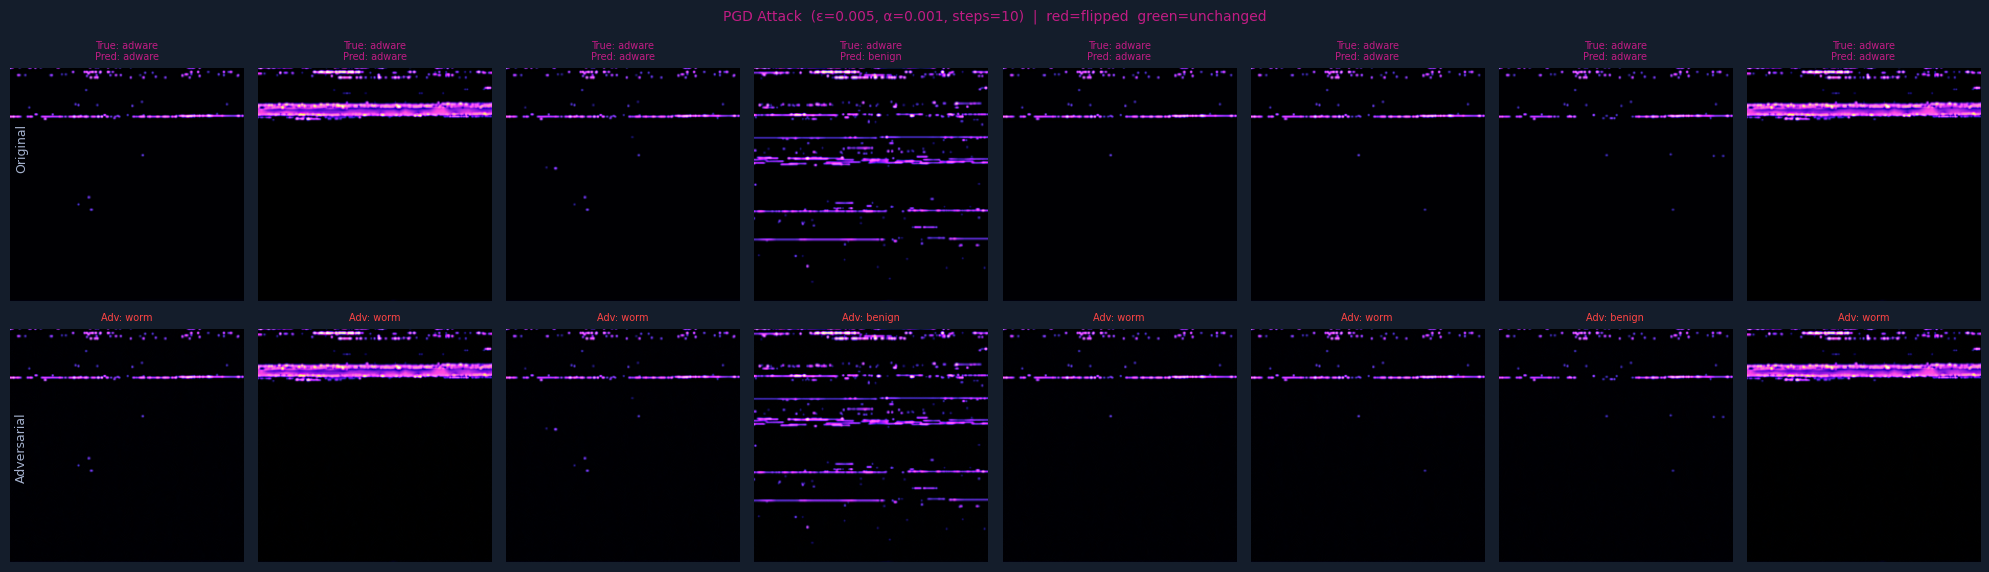

In [8]:
# ─────────────────────────────────────────────
# VISUALIZE FIRST BATCH
# ─────────────────────────────────────────────
sample_images, sample_labels = next(iter(test_loader))
sample_images, sample_labels = sample_images.to(device), sample_labels.to(device)
show_pgd_examples(sample_images, sample_labels, n=8)


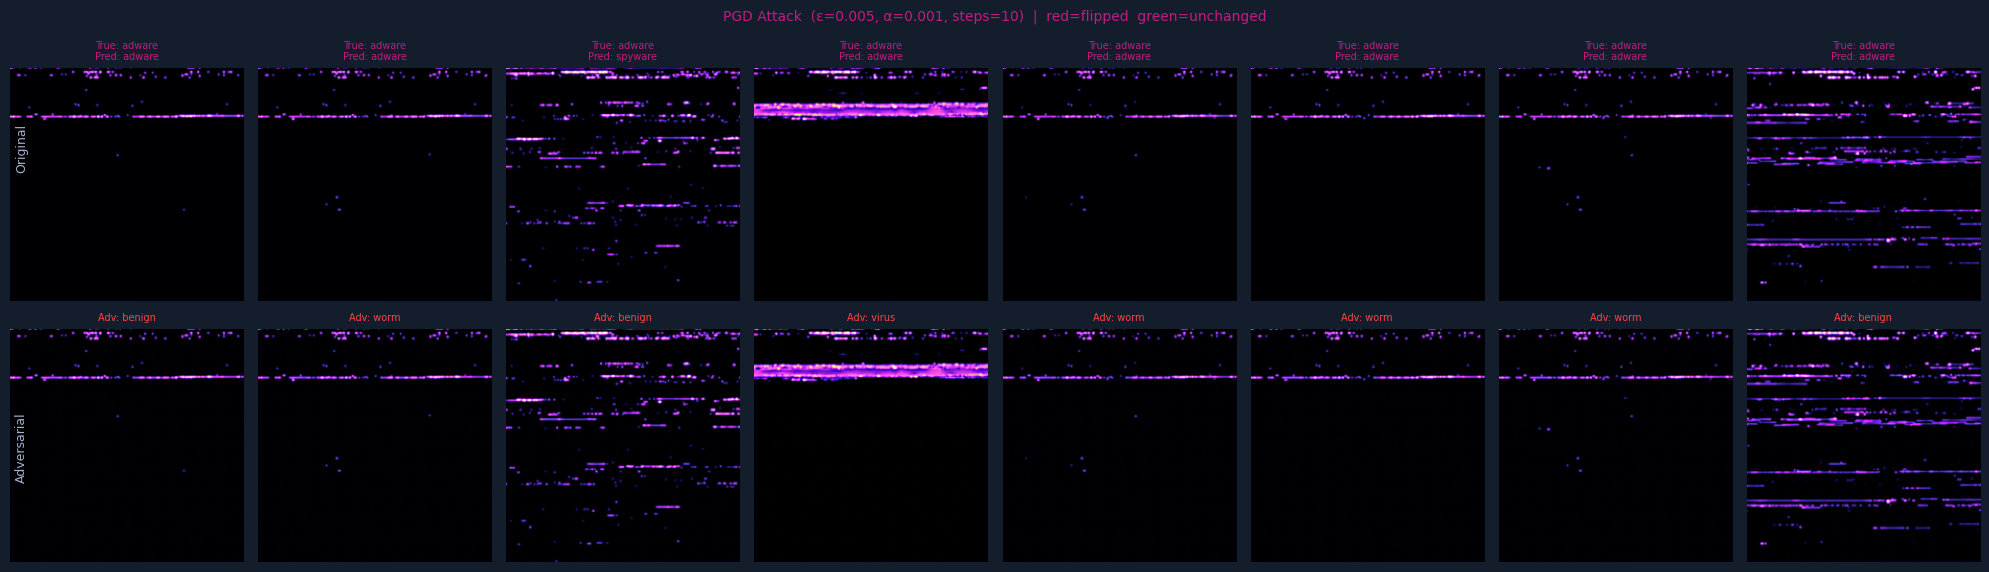

In [9]:
BATCH_INDEX = 2  # change this number

for i, (imgs, lbls) in enumerate(test_loader):
    if i == BATCH_INDEX:
        sample_images, sample_labels = imgs.to(device), lbls.to(device)
        break

show_pgd_examples(sample_images, sample_labels, n=8)